In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter, sobel
import matplotlib.cm as cm


# Set random seeds for reproducibility
RANDOM_SEED = 42

import random

# Seed all random number generators
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"Random seed set to {RANDOM_SEED} for reproducibility")
sys.path.append('/home/esli/GenMatter')

from gestalt_experiment_algorithm import *

Random seed set to 42 for reproducibility


In [5]:
explore_scene = 'scene_00016'
explore_texture = 'texture_07'
custom_hyperparams = {
    "number_of_blobs": 100,
    "number_of_hyperblobs": 5,
    "num_seeded_runs": 1,
}

number_of_blobs = custom_hyperparams["number_of_blobs"]
number_of_hyperblobs = custom_hyperparams["number_of_hyperblobs"]

print(f"Scene: {explore_scene}")
print(f"Texture: {explore_texture}")
print(f"Number of blobs: {number_of_blobs}")
print(f"Number of hyperblobs: {number_of_hyperblobs}")

Scene: scene_00016
Texture: texture_07
Number of blobs: 100
Number of hyperblobs: 5


In [6]:
def load_six_frame_gestalt_data(scene, texture):
    """Load depth and flow data for first 6 frames only"""
    # Load depth data from six-frame file
    depth_file = os.path.join('/home/esli/GenMatter/assets/from_thomas', 
                               scene, texture, 'output_six_frame_depths.npz')
    if not os.path.exists(depth_file):
        raise FileNotFoundError(f"Depth file not found: {depth_file}")
    
    depth_data = np.load(depth_file)
    if 'depths' in depth_data:
        inv_rel_depth = depth_data['depths']
    else:
        inv_rel_depth = next(iter(depth_data.values()))
    
    # Process depth data (matching load_gestalt_data processing)
    clipped_inverse_depth = np.clip(inv_rel_depth, 5, 1500)
    epsilon = 1e-6
    depth = 3000.0 / (clipped_inverse_depth + epsilon)
    depth = np.clip(depth, 0.25, 20.0)
    
    # Only use first 6 frames of depth
    depth = depth[:6]
    
    # Load flow data
    flow_file = os.path.join('/home/esli/GenMatter/raft_flows',
                             f'raft_flows_{scene}_{texture}.npz')
    if not os.path.exists(flow_file):
        raise FileNotFoundError(f"Flow file not found: {flow_file}")
    
    flow_data = np.load(flow_file)
    if 'flow' in flow_data:
        flow = flow_data['flow']
    else:
        flow = next(iter(flow_data.values()))
    
    # Only use first 5 frames of flow (for 6 depth frames)
    flow = flow[:5]
    
    return depth, flow


Depth shape: (6, 1000, 1000)
Flow shape: (5, 520, 960, 2)


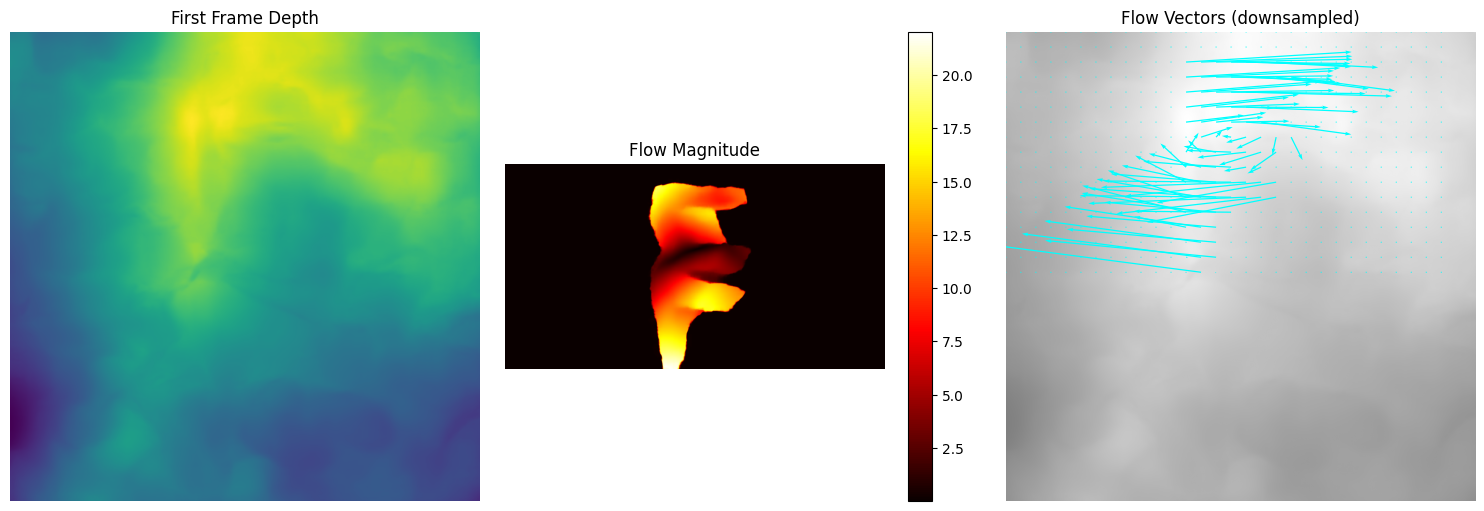

In [7]:
depth, flow = load_six_frame_gestalt_data(explore_scene, explore_texture)

print(f"Depth shape: {depth.shape}")  # [6, H, W]
print(f"Flow shape: {flow.shape}")    # [5, H, W, 2]

# Visualize first frame
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Depth map
axes[0].imshow(depth[0], cmap='viridis')
axes[0].set_title('First Frame Depth')
axes[0].axis('off')

# Flow magnitude
flow_mag = np.sqrt(flow[0, :, :, 0]**2 + flow[0, :, :, 1]**2)
im1 = axes[1].imshow(flow_mag, cmap='hot')
axes[1].set_title('Flow Magnitude')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Flow vectors (downsampled for visibility)
step = 32
y, x = np.mgrid[0:flow.shape[1]:step, 0:flow.shape[2]:step]
u = flow[0, ::step, ::step, 0]
v = flow[0, ::step, ::step, 1]
axes[2].imshow(depth[0], cmap='gray', alpha=0.5)
axes[2].quiver(x, y, u, -v, color='cyan', scale=50)
axes[2].set_title('Flow Vectors (downsampled)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Depth shape: (6, 1000, 1000)
Flow shape: (5, 520, 960, 2)


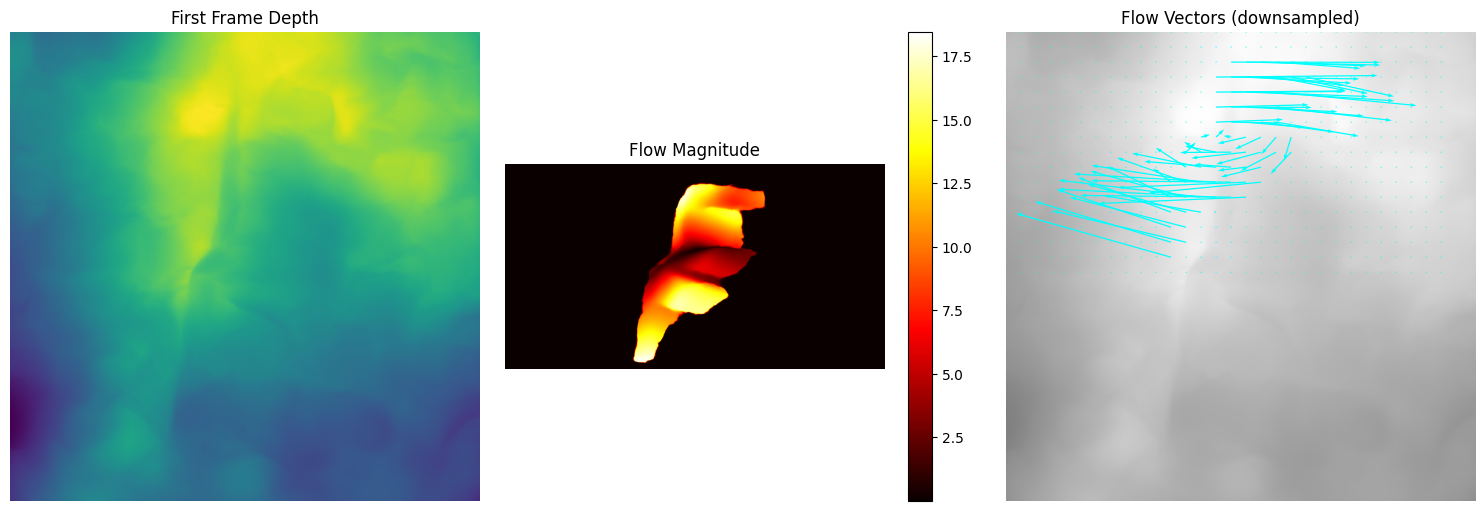

In [9]:
depth, flow = load_six_frame_gestalt_data(explore_scene, explore_texture)

print(f"Depth shape: {depth.shape}")  # [6, H, W]
print(f"Flow shape: {flow.shape}")    # [5, H, W, 2]

# Visualize first frame
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Depth map
axes[0].imshow(depth[4], cmap='viridis')
axes[0].set_title('First Frame Depth')
axes[0].axis('off')

# Flow magnitude
flow_mag = np.sqrt(flow[4, :, :, 0]**2 + flow[4, :, :, 1]**2)
im1 = axes[1].imshow(flow_mag, cmap='hot')
axes[1].set_title('Flow Magnitude')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Flow vectors (downsampled for visibility)
step = 32
y, x = np.mgrid[0:flow.shape[1]:step, 0:flow.shape[2]:step]
u = flow[4, ::step, ::step, 0]
v = flow[4, ::step, ::step, 1]
axes[2].imshow(depth[4], cmap='gray', alpha=0.5)
axes[2].quiver(x, y, u, -v, color='cyan', scale=50)
axes[2].set_title('Flow Vectors (downsampled)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

/var/tmp/ipykernel_14259/425784783.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


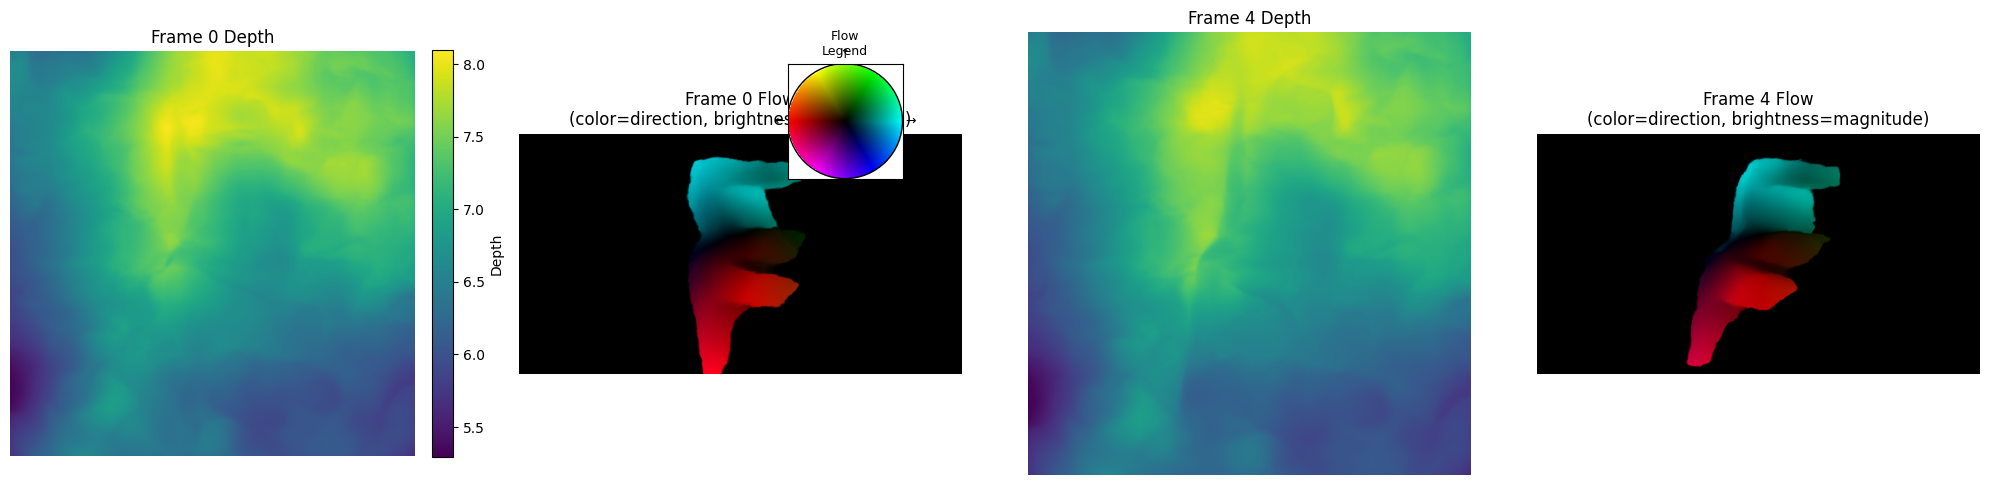

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize depth and flow for frames 0 and 4, 1 row x 4 columns (depth0, flow0, depth4, flow4)
frames = [0, 4]

# Gather limits for consistent colormaps
depth_vmin = np.min(depth)
depth_vmax = np.max(depth)

flow_magnitudes = [np.sqrt(np.sum(flow[f, :, :, :]**2, axis=-1)) for f in frames]
flow_mag_max = max(np.max(mag) for mag in flow_magnitudes)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, frame in enumerate(frames):
    # --- Depth ---
    ax_depth = axes[2*idx]
    im_depth = ax_depth.imshow(depth[frame], cmap='viridis', vmin=depth_vmin, vmax=depth_vmax)
    ax_depth.set_title(f'Frame {frame} Depth', fontsize=12)
    ax_depth.axis('off')
    if idx == 0:
        cbar = plt.colorbar(im_depth, ax=ax_depth, fraction=0.046, pad=0.04)
        cbar.set_label('Depth')

    # --- Flow (HSV encoding with explicit legend and explanation) ---
    ax_flow = axes[2*idx + 1]
    fx = flow[frame, :, :, 0]
    fy = flow[frame, :, :, 1]
    flow_mag = np.sqrt(fx**2 + fy**2)
    flow_ang = np.arctan2(-fy, fx)  # standard image coordinates: up negative

    # Hue encodes direction, brightness encodes magnitude (as usual in flow visualizations)
    # Map angle from [-pi, pi] -> [0, 1] for HSV cmap
    ang_norm = ((flow_ang + np.pi) / (2 * np.pi)) % 1.0
    mag_norm = np.clip(flow_mag / flow_mag_max, 0, 1)

    hsv_img = np.zeros(fx.shape + (3,), dtype=np.float32)
    hsv_img[..., 0] = ang_norm       # Hue: direction
    hsv_img[..., 1] = 1.0            # Full saturation
    hsv_img[..., 2] = mag_norm       # Value: normalized magnitude

    # Convert HSV to RGB using matplotlib; shape: (H, W, 3), values in [0,1]
    from matplotlib.colors import hsv_to_rgb
    rgb_img = hsv_to_rgb(hsv_img)
    ax_flow.imshow(rgb_img)
    ax_flow.set_title(
        f'Frame {frame} Flow\n(color=direction, brightness=magnitude)', fontsize=12)
    ax_flow.axis('off')

    # Add orientation+brightness color wheel in first flow plot only
    if idx == 0:
        from matplotlib.patches import Circle
        # Inset: color wheel for HSV flow legend
        inset_ax = fig.add_axes([0.38, 0.65, 0.09, 0.23])  # relative to figure [left, bottom, width, height]
        res = 120
        cy, cx = np.ogrid[-1:1:res*1j, -1:1:res*1j]
        mag_grid = np.sqrt(cx**2 + cy**2)
        ang_grid = (np.arctan2(-cy, cx) + np.pi) / (2 * np.pi)
        hsv_cw = np.ones((res, res, 3), dtype=np.float32)
        hsv_cw[..., 0] = ang_grid       # Hue: direction
        hsv_cw[..., 2] = np.clip(mag_grid, 0, 1)    # Value: radial magnitude
        rgb_cw = hsv_to_rgb(hsv_cw)
        # Fill outside circle with white
        mask = mag_grid > 1
        rgb_cw[mask] = 1.0
        inset_ax.imshow(rgb_cw, origin='lower', extent=[-1,1,-1,1])
        inset_ax.add_patch(Circle((0,0),1, fill=False, color='k', lw=1))
        inset_ax.set_xticks([]); inset_ax.set_yticks([])
        inset_ax.set_title("Flow\nLegend", fontsize=9)
        # Explicit labels for North/East/South/West
        inset_ax.text(0,1.05,"↑",ha="center",va="bottom",fontsize=9)
        inset_ax.text(1.05,0,"→",ha="left",va="center",fontsize=9)
        inset_ax.text(0,-1.1,"↓",ha="center",va="top",fontsize=9)
        inset_ax.text(-1.05,0,"←",ha="right",va="center",fontsize=9)
        # Label for brightness
        inset_ax.text(0,-1.28,"Brighter = faster",ha="center",va="top",fontsize=8)

plt.tight_layout()
plt.show()
